#### 1. Import Libraries

In [2]:
import tensorflow as tf
import keras

In [13]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam

np.random.seed(42)

tf.random.set_seed(42)

#### 2. Load Processed Dataset

In [14]:
processed_path = Path("..//data//processed")

df = pd.read_csv(
    processed_path / "hr_feature_engineered.csv"
)

df.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,...,ManagerStabilityLevel_Medium,ManagerStabilityLevel_Very High,ExperienceMaturity_Beginner,ExperienceMaturity_Developing,ExperienceMaturity_Experienced,ExperienceMaturity_Veteran,TenureCommitment_High,TenureCommitment_Low,TenureCommitment_Moderate,TenureCommitment_Very High
0,41,1,1102,1,2,2,94,3,2,4,...,0,0,1,0,0,0,1,0,0,0
1,49,0,279,8,1,3,61,2,2,2,...,0,0,1,0,0,0,0,0,0,1
2,37,1,1373,2,2,4,92,2,1,3,...,0,0,1,0,0,0,0,1,0,0
3,33,0,1392,3,4,4,56,3,1,3,...,0,0,0,1,0,0,0,0,0,1
4,27,0,591,2,1,1,40,3,1,2,...,0,0,0,1,0,0,0,0,1,0


In [15]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 1470
Columns : 115


#### 3. Separate Features & Target

In [16]:
TARGET = "Attrition"

X = df.drop(columns=TARGET)

y = df[TARGET]

In [17]:
print(X.shape)

print(y.shape)

(1470, 114)
(1470,)


#### 4. Train Test Split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [19]:
print(X_train.shape)

print(X_test.shape)

(1176, 114)
(294, 114)


#### 5. Standard Scaling

Unlike XGBoost,
Neural Networks work MUCH better after scaling.

In [21]:
# Fit Scaler
scaler = StandardScaler()

In [22]:
X.select_dtypes(include="object").columns.tolist()

[]

In [23]:
# Train
X_train_scaled = scaler.fit_transform(
    X_train
)

In [24]:
# Test
X_test_scaled = scaler.transform(
    X_test
)

In [25]:
# Save Scaler
models_path = Path("..//models")

models_path.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    scaler,
    models_path / "standard_scaler.pkl"
)

['..\\models\\standard_scaler.pkl']

In [26]:
print(X_train_scaled.shape)

print(X_test_scaled.shape)

(1176, 114)
(294, 114)


#### 6. Calculate Class Weights

In [27]:
# Calculate
classes = np.unique(y_train)

weights = compute_class_weight(

    class_weight="balanced",

    classes=classes,

    y=y_train
)

In [28]:
# Convert to Dictionary
class_weights = dict(

    zip(
        classes,
        weights
    )
)

class_weights

{np.int64(0): np.float64(0.5963488843813387),
 np.int64(1): np.float64(3.094736842105263)}

#### 7. Create Output Folder

In [29]:
evaluation_path = Path(
    "..//reports//figures//model_evaluation//neural_network"
)

evaluation_path.mkdir(

    parents=True,

    exist_ok=True
)

#### 8. Build Neural Network

In [32]:
model = Sequential([
    
    Dense(
        128,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        64,
        activation="relu"
    ),

    BatchNormalization(),

    Dropout(0.30),

    Dense(
        32,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        1,
        activation="sigmoid"
    )

])

In [33]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        14,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,857 (101.00 KB)

 Trainable params: 25,473 (99.50 KB)

 Non-trainable params: 384 (1.50 KB)

#### 9. Compile Model

In [34]:
model.compile(

    optimizer=Adam(
        learning_rate=0.001
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [35]:
model.optimizer

#### 10. Callbacks

In [36]:
# 10.1 Early Stopping
early_stopping = EarlyStopping(

    monitor="val_loss",

    patience=15,

    restore_best_weights=True,

    verbose=1
)

In [37]:
# 10.2 Reduce Learning Rate
reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=5,

    min_lr=1e-6,

    verbose=1
)

In [38]:
# 10.3 Model Checkpoint
checkpoint = ModelCheckpoint(

    filepath="..//models//best_neural_network.keras",

    monitor="val_loss",

    save_best_only=True,

    verbose=1
)

#### 11. Train Model

In [39]:
# 11.1 Start Timer
start_time = time.time()

In [40]:
# 11.2 Train
history = model.fit(

    X_train_scaled,

    y_train,

    validation_split=0.20,

    epochs=100,

    batch_size=32,

    class_weight=class_weights,

    callbacks=[
        early_stopping,
        reduce_lr,
        checkpoint
    ],

    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3126 - auc: 0.5604 - loss: 0.8506 - precision: 0.1628 - recall: 0.8246
Epoch 1: val_loss improved from None to 0.64581, saving model to ..//models//best_neural_network.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.3606 - auc: 0.6260 - loss: 0.7865 - precision: 0.1765 - recall: 0.8200 - val_accuracy: 0.6229 - val_auc: 0.7964 - val_loss: 0.6458 - val_precision: 0.2941 - val_recall: 0.8750 - learning_rate: 0.0010
Epoch 2/100
29/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5346 - auc: 0.7282 - loss: 0.6315 - precision: 0.2285 - recall: 0.8439
Epoch 2: val_loss improved from 0.64581 to 0.58003, saving model to ..//models//best_neural_network.keras
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.5404 - auc: 0.7252 - loss: 0.6307 - precision: 0.2288 - recall: 0.7933 - val_accuracy: 0.7246 - val_auc: 0.8379 - val_loss: 0.5800 - val_precision: 0.3684 - val_recall: 0.8750 - learning_rate: 0.0010
Epoch 3/1

In [41]:
# 11.3 Training Time
training_time = time.time() - start_time

print(f"Training Time : {training_time:.2f} seconds")

Training Time : 60.68 seconds


#### 12. Training History

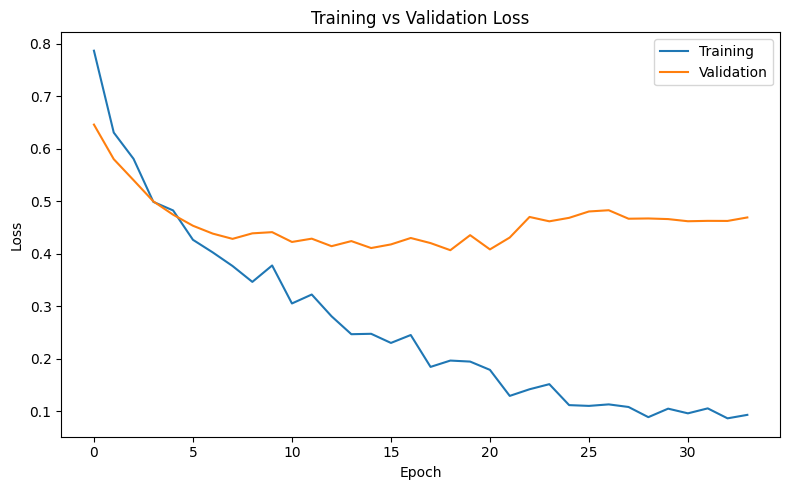

In [42]:
# 12.1 Loss Curve
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.title("Training vs Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_evaluation/neural_network/loss_curve.png",
    dpi=300
)

plt.show()

plt.close()

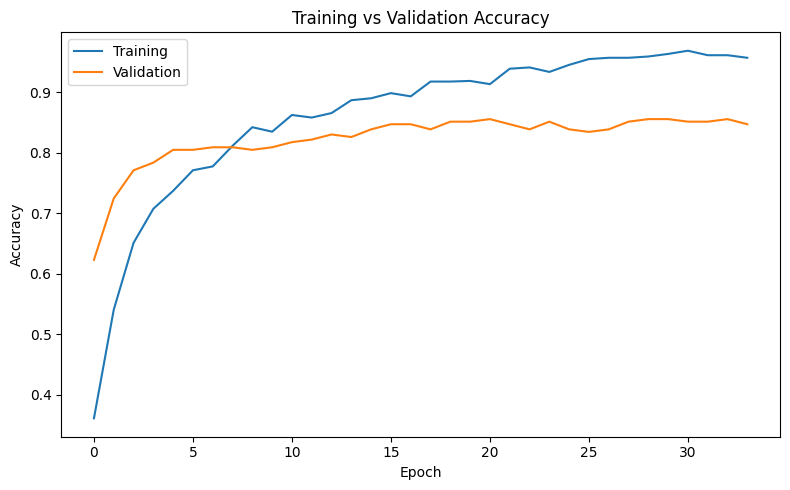

In [43]:
# 12.2 Accuracy Curve
plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../reports/figures/model_evaluation/neural_network/accuracy_curve.png",
    dpi=300
)

plt.show()

plt.close()

#### 13. Model Evaluation

In [44]:
# 13.1 Predictions
probabilities = model.predict(
    X_test_scaled
)

predictions = (
    probabilities >= 0.5
).astype(int)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [45]:
# 13.2 Metrics
nn_metrics = {

    "Accuracy": accuracy_score(
        y_test,
        predictions
    ),

    "Precision": precision_score(
        y_test,
        predictions
    ),

    "Recall": recall_score(
        y_test,
        predictions
    ),

    "F1 Score": f1_score(
        y_test,
        predictions
    ),

    "ROC-AUC": roc_auc_score(
        y_test,
        probabilities
    ),

    "PR-AUC": average_precision_score(
        y_test,
        probabilities
    )
}

pd.DataFrame(
    nn_metrics,
    index=["Neural Network"]
)

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Neural Network,0.836735,0.488889,0.468085,0.478261,0.787406,0.493432


In [46]:
# 13.3 Classification Report
report = classification_report(
    y_test,
    predictions
)

print(report)

with open(
    "..//reports//tables//neural_network_classification_report.txt",
    "w"
) as file:

    file.write(report)

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       247
           1       0.49      0.47      0.48        47

    accuracy                           0.84       294
   macro avg       0.69      0.69      0.69       294
weighted avg       0.83      0.84      0.84       294



<Figure size 500x500 with 0 Axes>

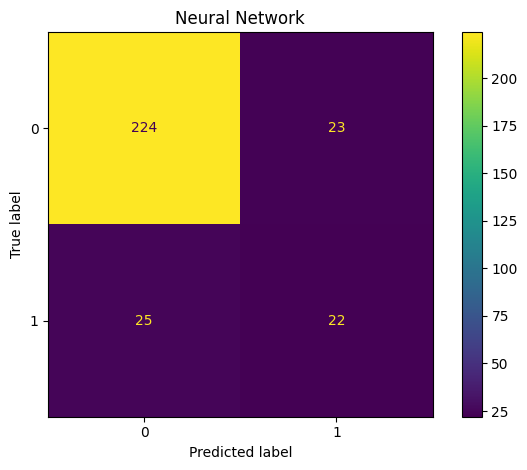

In [47]:
# 13.4 Confusion Matrix
plt.figure(figsize=(5,5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title("Neural Network")

plt.tight_layout()

plt.savefig(
    "..//reports//figures//model_evaluation//neural_network//confusion_matrix.png",
    dpi=300
)

plt.show()

plt.close()

<Figure size 600x500 with 0 Axes>

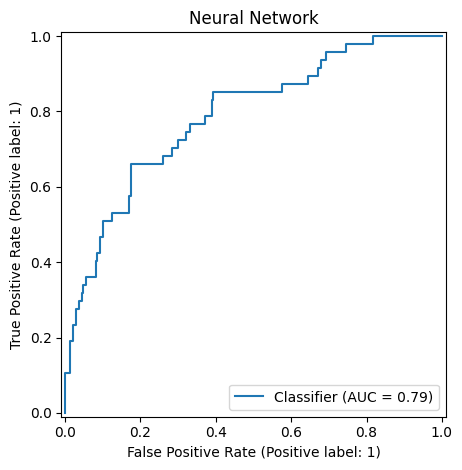

In [48]:
# 13.5 ROC Curve
plt.figure(figsize=(6,5))

RocCurveDisplay.from_predictions(
    y_test,
    probabilities
)

plt.title("Neural Network")

plt.tight_layout()

plt.savefig(
    "..//reports//figures//model_evaluation//neural_network//roc_curve.png",
    dpi=300
)

plt.show()

plt.close()

<Figure size 600x500 with 0 Axes>

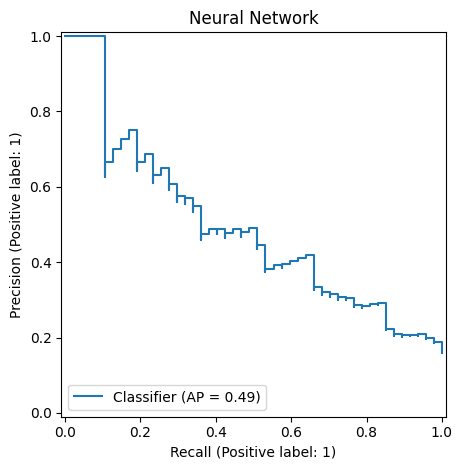

In [49]:
# 13.6 Precision-Recall Curve
plt.figure(figsize=(6,5))

PrecisionRecallDisplay.from_predictions(
    y_test,
    probabilities
)

plt.title("Neural Network")

plt.tight_layout()

plt.savefig(
    "..//reports//figures//model_evaluation//neural_network//precision_recall_curve.png",
    dpi=300
)

plt.show()

plt.close()

#### 14. Compare with XGBoost

In [50]:
# 14.1 Load XGBoost Results
xgb_results = pd.read_csv(
    "..//reports//tables//xgboost_experiment_results.csv"
)

xgb_best = xgb_results[
    xgb_results["Experiment"]=="ADASYN"
].iloc[0]

In [51]:
# 14.2 Comparison Table
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ],

    "XGBoost":[

        xgb_best["Accuracy"],
        xgb_best["Precision"],
        xgb_best["Recall"],
        xgb_best["F1 Score"],
        xgb_best["ROC-AUC"],
        xgb_best["PR-AUC"]

    ],

    "Neural Network":[

        nn_metrics["Accuracy"],
        nn_metrics["Precision"],
        nn_metrics["Recall"],
        nn_metrics["F1 Score"],
        nn_metrics["ROC-AUC"],
        nn_metrics["PR-AUC"]

    ]

})

comparison

,Metric,XGBoost,Neural Network
0,Accuracy,0.8605,0.836735
1,Precision,0.6250,0.488889
2,Recall,0.3191,0.468085
3,F1 Score,0.4225,0.478261
4,ROC-AUC,0.7925,0.787406
5,PR-AUC,0.5287,0.493432


In [52]:
# 14.3 Save Table
comparison.to_csv(

    "..//reports//tables//xgboost_vs_neural_network.csv",

    index=False
)

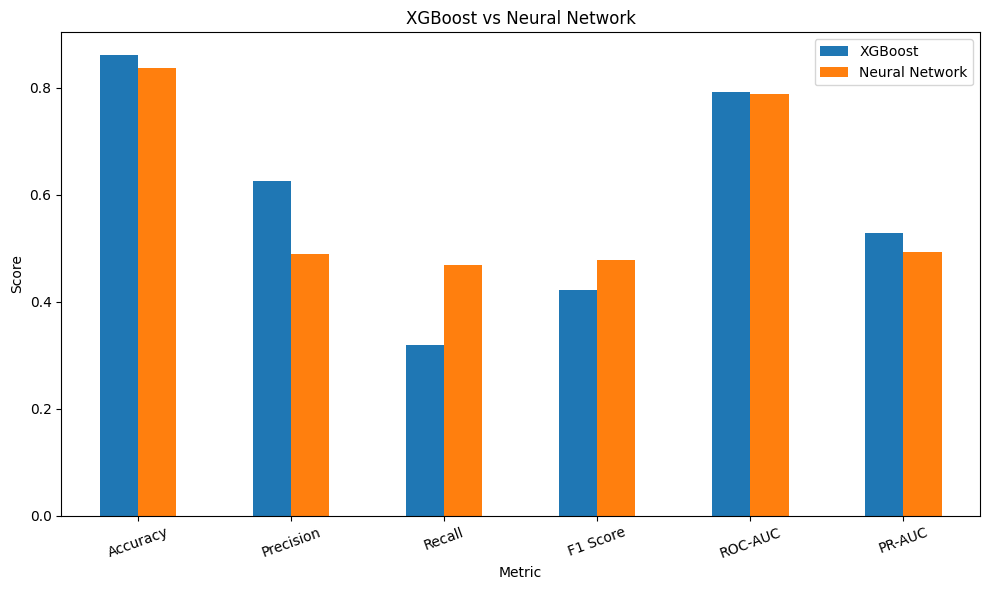

In [53]:
# 14.4 Comparison Plot
comparison_plot = comparison.set_index("Metric")

comparison_plot.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("XGBoost vs Neural Network")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "..//reports//figures//model_comparison//xgboost_vs_neural_network.png",
    dpi=300
)

plt.show()

plt.close()

#### 15. Save Final Model

In [54]:
model.save(
    "..//models//neural_network.keras"
)

print("Neural Network saved successfully.")

Neural Network saved successfully.


# Conclusion

A Deep Neural Network was developed and evaluated for employee attrition prediction using standardized features and balanced class weights.

The model incorporated Batch Normalization, Dropout regularization, Early Stopping, Learning Rate Scheduling, and Model Checkpointing to improve generalization and reduce overfitting.

Performance was compared against the best XGBoost model (ADASYN) using Accuracy, Precision, Recall, F1 Score, ROC-AUC, and PR-AUC.

Both models demonstrated strong predictive capability, providing complementary approaches for employee attrition prediction.

The trained Neural Network has been saved for deployment and will be further interpreted in the next notebook using Explainable AI (SHAP), where feature contributions and individual employee predictions will be analyzed.